In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
filePath = 'final_football_model_data.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,B365>2.5_missing,B365<2.5_missing,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,EarlySeason,RefereeAggression
0,2002-08-27,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,...,1,1,0.526316,0.523560,0.090000,0.994764,0.994764,0,0,0.0
1,2002-08-27,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,...,1,1,0.526316,0.523560,0.923077,0.994764,0.994764,0,0,0.0
2,2002-08-28,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,...,1,1,0.526316,0.523560,0.371111,0.994764,0.994764,0,0,0.0
3,2002-08-28,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,...,1,1,0.526316,0.523560,0.230769,0.994764,0.994764,0,0,0.0
4,2002-08-28,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,...,1,1,0.526316,0.523560,1.428571,0.994764,0.994764,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,2023-12-30,3.0,2.0,H,2.0,1.0,H,S Attwell,19.0,9.0,...,0,0,0.636943,0.425532,0.181333,0.668085,0.668085,1,0,5.0
7897,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,0,0,0.578035,0.480769,3.387097,0.831731,0.831731,1,0,3.0
7898,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,0,0,0.714286,0.347222,0.437500,0.486111,0.486111,1,0,5.7
7899,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,0,0,0.694444,0.370370,0.207143,0.533333,0.533333,0,1,4.7


              precision    recall  f1-score   support

           0       0.53      0.56      0.55       765
           1       0.57      0.54      0.56       816

    accuracy                           0.55      1581
   macro avg       0.55      0.55      0.55      1581
weighted avg       0.55      0.55      0.55      1581



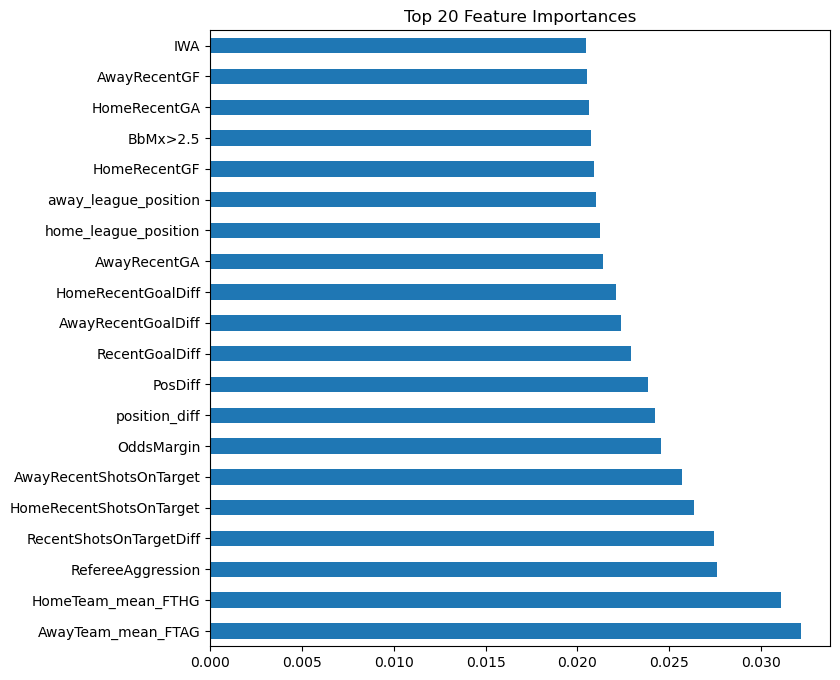

In [3]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus'
    ]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()

In [4]:
y_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ROC-AUC: 0.560
Confusion Matrix:
[[429 336]
 [373 443]]


In [5]:
print(feat_importances)

IWH                  0.018959
IWD                  0.016741
IWA                  0.020485
WHH                  0.020287
WHD                  0.017139
                       ...   
OU_OddsMargin        0.006566
OverUnderRatio       0.006178
Weekend              0.003868
EarlySeason          0.004421
RefereeAggression    0.027585
Length: 148, dtype: float64


In [6]:
feat_importances.to_string('feature_importances.txt')

              precision    recall  f1-score   support

           0       0.51      0.51      0.51       783
           1       0.52      0.51      0.51       798

    accuracy                           0.51      1581
   macro avg       0.51      0.51      0.51      1581
weighted avg       0.51      0.51      0.51      1581



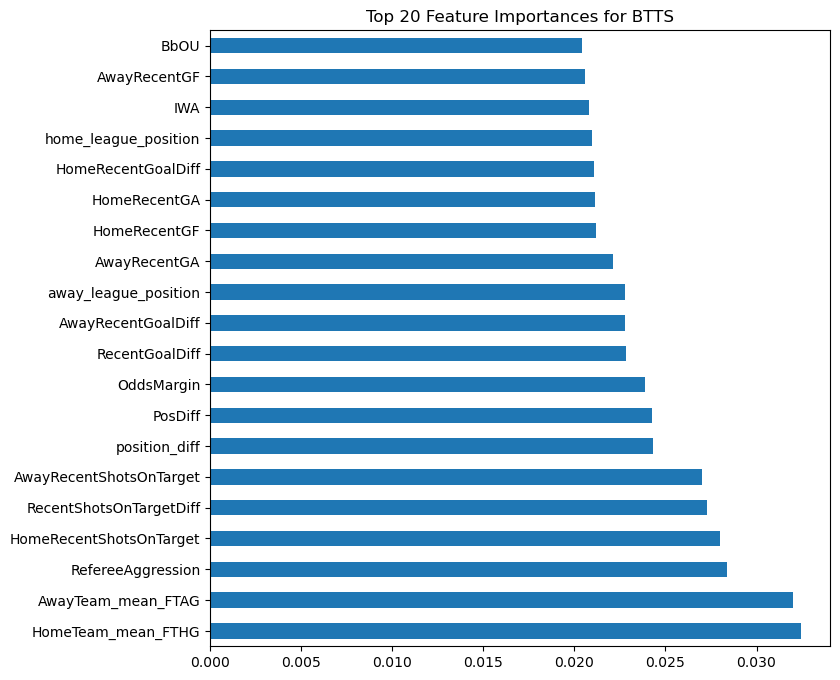

In [7]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus'
    ]

df['BTTS'] = ((df['FTHG'] > 0) & (df['FTAG'] > 0)).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['BTTS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for BTTS')
plt.show()

In [8]:
y_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ROC-AUC: 0.513
Confusion Matrix:
[[402 381]
 [392 406]]


              precision    recall  f1-score   support

           0       0.64      0.76      0.69       876
           1       0.61      0.46      0.52       705

    accuracy                           0.63      1581
   macro avg       0.62      0.61      0.61      1581
weighted avg       0.62      0.63      0.62      1581



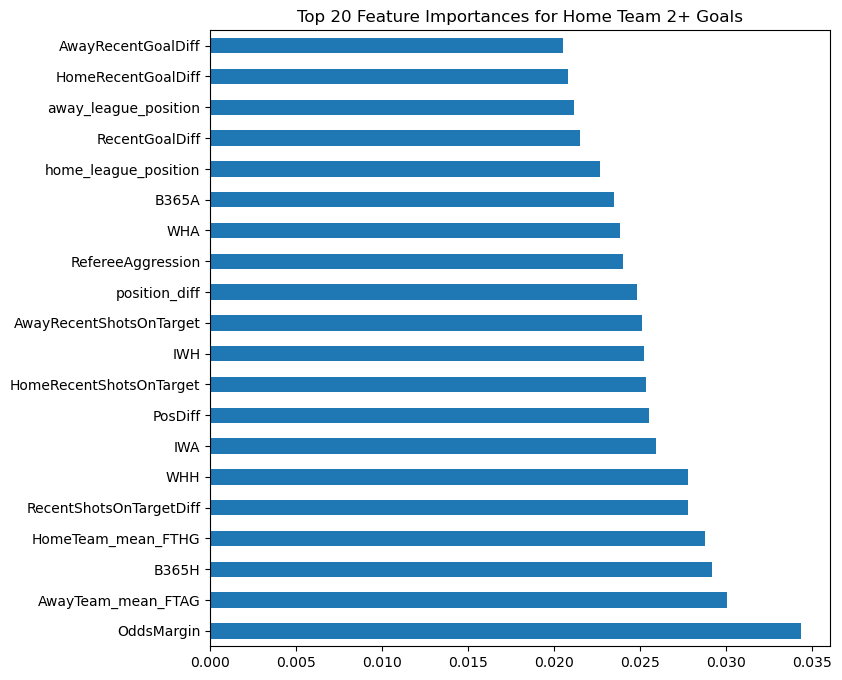

In [4]:
df['Home_2plus'] = (df['FTHG'] >= 2).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['Home_2plus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for Home Team 2+ Goals')
plt.show()

In [15]:
feat_importances.nlargest(20).to_string('feature_importances_home2plus.txt')

In [5]:
y_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ROC-AUC: 0.652
Confusion Matrix:
[[666 210]
 [380 325]]


In [6]:
y_proba = rf.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3]:
    print(f"\nThreshold: {threshold}")
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(classification_report(y_test, y_pred_thresh, digits=3))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Threshold: 0.5
              precision    recall  f1-score   support

           0      0.639     0.747     0.689       876
           1      0.602     0.477     0.532       705

    accuracy                          0.626      1581
   macro avg      0.621     0.612     0.610      1581
weighted avg      0.623     0.626     0.619      1581

Confusion Matrix:
[[654 222]
 [369 336]]
ROC-AUC: 0.6521527575374849

Threshold: 0.4
              precision    recall  f1-score   support

           0      0.669     0.498     0.571       876
           1      0.526     0.694     0.599       705

    accuracy                          0.585      1581
   macro avg      0.598     0.596     0.585      1581
weighted avg      0.605     0.585     0.583      1581

Confusion Matrix:
[[436 440]
 [216 489]]
ROC-AUC: 0.6521527575374849

Threshold: 0.35
              precision    recall  f1-score   support

           0      0.697     0.365     0.479       876
           1      0.504     0.803     0.620       


XGBoost Results (Home 2+):
              precision    recall  f1-score   support

           0      0.645     0.766     0.700       876
           1      0.620     0.475     0.538       705

    accuracy                          0.636      1581
   macro avg      0.632     0.621     0.619      1581
weighted avg      0.634     0.636     0.628      1581

Confusion Matrix:
[[671 205]
 [370 335]]
ROC-AUC: 0.6787727905696428


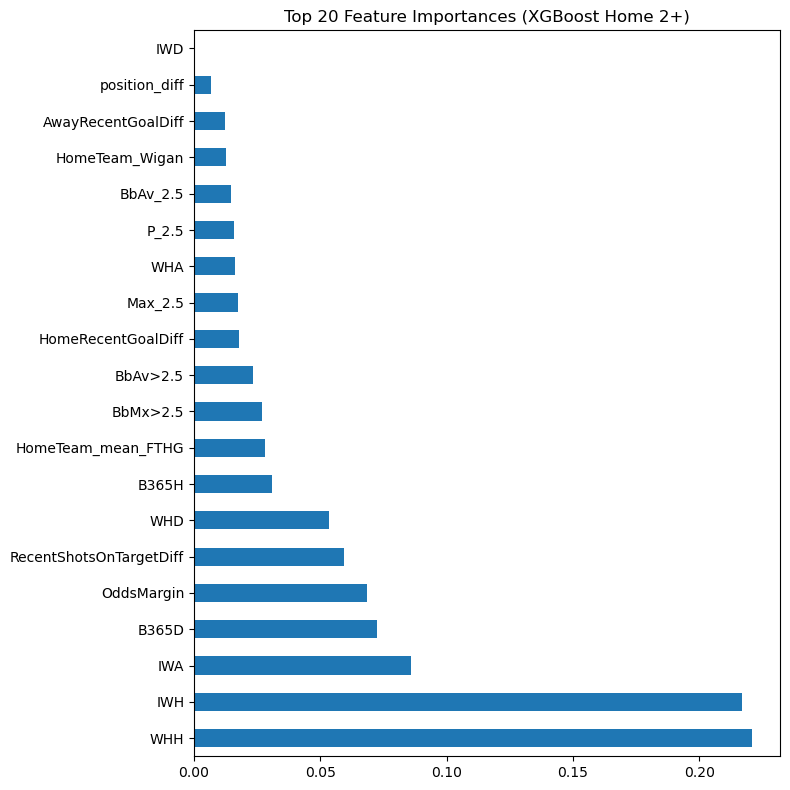

In [7]:
X_train = X_train.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_'))
X_test = X_test.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_'))

xgb_model = xgb.XGBClassifier(
    n_estimators=10,        
    max_depth=2, 
    n_jobs=1, 
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost Results (Home 2+):")
print(classification_report(y_test, y_pred_xgb, digits=3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances (XGBoost Home 2+)')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.72      0.90      0.80      1075
           1       0.54      0.25      0.34       506

    accuracy                           0.69      1581
   macro avg       0.63      0.58      0.57      1581
weighted avg       0.66      0.69      0.65      1581



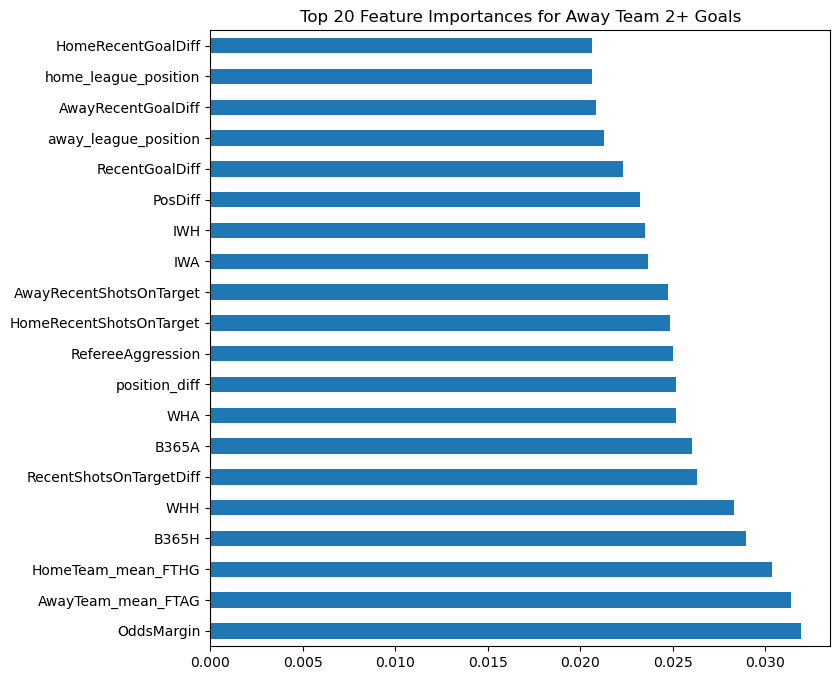

In [8]:
df['Away_2plus'] = (df['FTAG'] >= 2).astype(int)

X = df.drop(columns=cols_to_drop + ['BTTS', 'Home_2plus', 'Away_2plus'], errors='ignore')
y = df['Away_2plus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances for Away Team 2+ Goals')
plt.show()

In [9]:
y_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ROC-AUC: 0.657
Confusion Matrix:
[[967 108]
 [379 127]]


In [13]:
feat_importances.nlargest(20).to_string('feature_importances_away2plus.txt')

In [10]:
y_proba = rf.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3]:
    print(f"\nThreshold: {threshold}")
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(classification_report(y_test, y_pred_thresh, digits=3))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Threshold: 0.5
              precision    recall  f1-score   support

           0      0.719     0.892     0.796      1075
           1      0.530     0.259     0.348       506

    accuracy                          0.689      1581
   macro avg      0.625     0.575     0.572      1581
weighted avg      0.659     0.689     0.653      1581

Confusion Matrix:
[[959 116]
 [375 131]]
ROC-AUC: 0.6571605846125562

Threshold: 0.4
              precision    recall  f1-score   support

           0      0.751     0.761     0.756      1075
           1      0.478     0.464     0.471       506

    accuracy                          0.666      1581
   macro avg      0.614     0.613     0.613      1581
weighted avg      0.664     0.666     0.665      1581

Confusion Matrix:
[[818 257]
 [271 235]]
ROC-AUC: 0.6571605846125562

Threshold: 0.35
              precision    recall  f1-score   support

           0      0.771     0.653     0.707      1075
           1      0.443     0.587     0.505       


XGBoost Results (Away 2+):
              precision    recall  f1-score   support

           0      0.718     0.923     0.808      1075
           1      0.585     0.231     0.331       506

    accuracy                          0.701      1581
   macro avg      0.652     0.577     0.570      1581
weighted avg      0.676     0.701     0.655      1581

Confusion Matrix:
[[992  83]
 [389 117]]
ROC-AUC: 0.6735637466678922


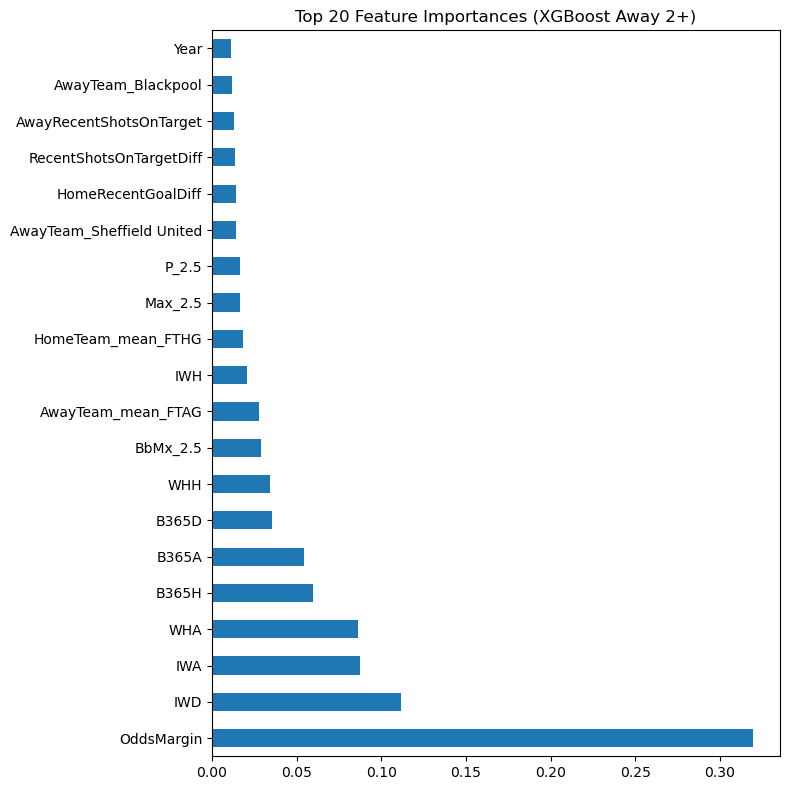

In [11]:
X_train = X_train.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_'))
X_test = X_test.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_'))

xgb_model = xgb.XGBClassifier(
    n_estimators=10,        
    max_depth=2, 
    n_jobs=1, 
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost Results (Away 2+):")
print(classification_report(y_test, y_pred_xgb, digits=3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances (XGBoost Away 2+)')
plt.tight_layout()
plt.show()